SImple code for the propagation of the electric field
At the beginning, Assume that the E field is simply given by a real image and propagate it by:
1. Direct Space propagation of the shifted beam OR
2. propagation in the Fourier space OR
3. propagation with the Angular spectrum method

image size= (300, 451)
Before: (512, 512)
After: (724, 724)
number of pixels= 512


/tmp/ipykernel_6538/2436538279.py:154: RuntimeWarning: invalid value encountered in log
  plt.imshow(np.log(magnitude_spectrum), cmap='hot')


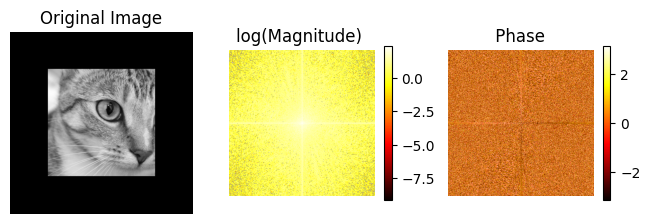

In [1]:
'''
March 2025
Giberto Chirico

Jupiter code to simulate the PROPAGATION  of a E field with the Fresnel integral
in real or in Fourier space.
For propation over a short distance (compared to the wavelngth) use the Fourier space
For a propagation over large distances use the direct space.

FIRST PANEL:

Here we  load a sample image (whatever), RGB and comnvert it in gray scale,
then perform the FFT in 2D. Then we will use also the Gaussian beam

This is thought to be in colab.
to load an image, first load the image in the "content" folder on colab.
then copy the exacgtf path of the file (right click -> copy path)
Use FLAG = 'gravel'  # or 'gravel
Prepare the image to be propagated
the image here is simply real

'''

from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
from skimage import data
from skimage.color import rgb2gray

def gaussian_random_field(N, s,A):
    """
    Generate a 2D random field with Gaussian autocorrelation of variance s^2.

    N : int
        Size of the matrix (NxN).
    s : float
        Standard deviation of the Gaussian autocorrelation.
    A: amplitude in phase
    # Example usage
    N = 128
    s = 5.0
    A = 190
    fieldR, fieldI = gaussian_random_field(N, s,A)
    """
    # Frequency grid
    kx = np.fft.fftfreq(N)
    ky = np.fft.fftfreq(N)
    kx, ky = np.meshgrid(kx, ky)
    k2 = kx**2 + ky**2

    # Desired power spectrum ~ exp(- (s^2 * k^2)/2 )
    psd = np.exp(-0.5 * (s**2) * (2*np.pi)**2 * k2)

    # Random complex field with Gaussian spectrum
    noise = A * (np.random.normal(size=(N,N)) + 1j*np.random.normal(size=(N,N)))
    field_ft = noise * np.sqrt(psd)

    # Inverse FFT to get spatial field
    fieldR = np.fft.ifft2(field_ft).real
    fieldI = np.fft.ifft2(field_ft).imag

    return fieldR,fieldI
################################################################
#################   MAIN ######################
# Load a sample image
FLAG = 'cat'  # or 'gravel

if FLAG == 'cat':
  cat     = data.chelsea()
  image = rgb2gray(cat)
elif FLAG == 'gravel':
  image   = data.gravel()
else:
  print ('choose a different image')

print ('image size=',image.shape)
dimq = np.min(image.shape)
imageq = image[0:dimq,0:dimq]

####  ADD RANDOM  phase

s = 5.0
A = 19
fieldR, fieldI = gaussian_random_field(dimq, s,A)
C_random_phase = np.exp(1j*np.angle(fieldR + 1j*fieldI))

#Cimageq = imageq * C_random_phase
Cimageq = imageq

################################################
######################## padding ###############
#@###### the padding is needed to avoid aliasing at the edge
################################################

############# THIS IS ONLY A PREPRATION
padint = 106

def mypad (image,padint):
  newdim0 = image.shape[0] + 2*padint
  newdim1 = image.shape[1] + 2*padint
  PadImage = np.zeros((newdim0,newdim1))
  PadImage[int(padint):int(newdim0-padint),int(padint):int(newdim1-padint)] = image
  return PadImage

# target size (for example, pad 50 pixels on each side)
pad_top, pad_bottom = padint, padint
pad_left, pad_right = padint, padint

padded = np.pad(
    Cimageq,
    pad_width=((pad_top, pad_bottom), (pad_left, pad_right)),
    mode='constant',
    constant_values=0  # black
)

image = padded
#image = mypad(image,padint)
print("Before:", image.shape)
padded = np.pad(image, ((106,106),(106,106)), mode='constant')
print("After:", padded.shape)

### assign a physical pixel size:
upix  = 0.3 ## um  This is an aribritrary choice due to the fact that typically the CMOS camera has pixsel size of this order
Npix  = image.shape[0]
print ('number of pixels=',Npix)
# Convert image to numpy array to do maths
image_array = np.array(image)[0:Npix,0:Npix]

############### THIS IS THE CORE OF THE ALGORITHM
# Perform FFT
fft_result  = np.fft.fft2(np.abs(image_array))
fft_shifted = np.fft.fftshift(fft_result)  # Shift zero frequency components to the center
Efft2       = fft_shifted                  # this is used later on for the propagation
######### THIS IS AN ESSENTIAL STEP for the propagation in the Fourier space
######### now compute the frequencies
frequenze           = np.fft.fftshift(np.fft.fftfreq(Npix,upix))   ######SHIFTED !!!!!

freq2x,freq2y       = np.meshgrid(frequenze,frequenze)       # and the meshgrid for image display and computation, also these are shifted

# Calculate magnitude spectrum
magnitude_spectrum = np.log(np.abs(fft_shifted) + 0.1)  # Add 1 to avoid log(0)
phase_spectrum     = np.angle(fft_shifted)
# Plot the results
plt.figure(figsize=(8, 5))

# Original Image
plt.subplot(1, 3, 1)
plt.imshow(np.abs(image_array), cmap='gray')
plt.title('Original Image')
plt.axis('off')

# Magnitude Spectrum
plt.subplot(1, 3, 2)
plt.imshow(np.log(magnitude_spectrum), cmap='hot')
plt.title('log(Magnitude) ')
plt.colorbar(shrink = 0.4)
plt.axis('off')

# Phase Spectrum
plt.subplot(1, 3, 3)
plt.imshow(phase_spectrum, cmap='hot')
plt.title(' Phase ')
plt.colorbar(shrink = 0.4)
plt.axis('off')
plt.show()


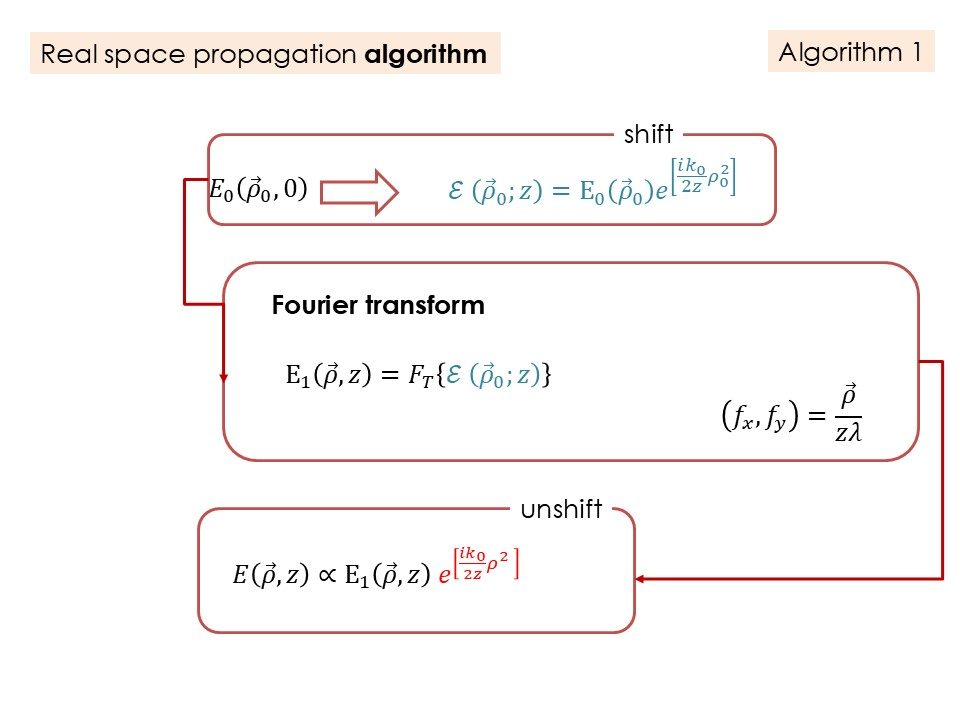

maximum phase in kernel: 648.4643028209784 103.20629921259841


Text(0.5, 1.0, 'Phase, Direct propagation by 90 [um]')

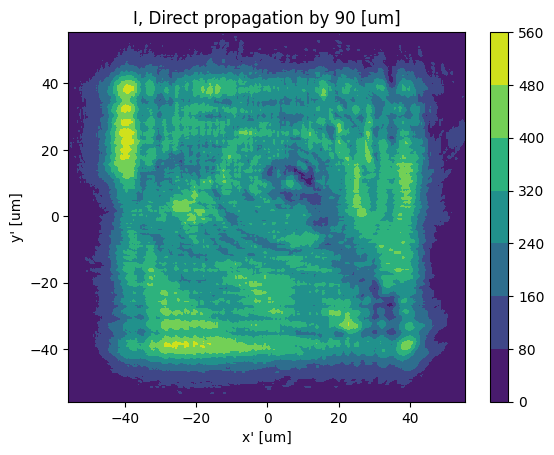

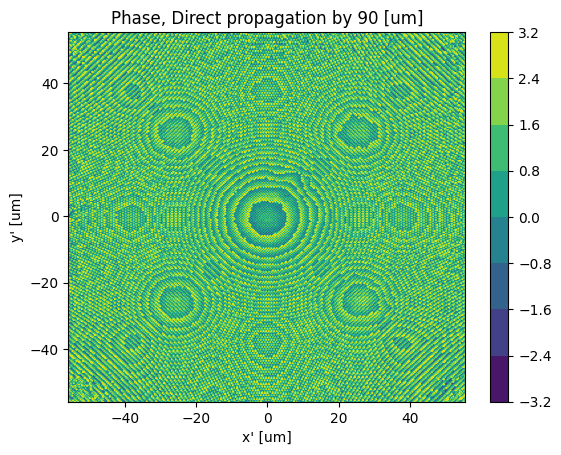

In [23]:
###########
############## this is the routine to propagate the image (cat or gravel)
################ propagation in the *** REAL SPACE  ***
################  square image

from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

############# propagation at z
wav   = 0.635
kappa = 1/wav
k0    = 2*np.pi/wav ### lambda = 635 nm

z     = 90  ###um

x                   = np.linspace(-Npix//2,Npix//2-1,Npix) * upix
xx0,yy0             = np.meshgrid(x,x)
rho02                = xx0**2+yy0**2
frequenze           = np.fft.fftshift(np.fft.fftfreq(Npix,upix))   ######SHIFTED !!!!!
xz                  = frequenze * wav * z    # this is the coordinate on the propoagated plane
xxz,yyz             = np.meshgrid(xz,xz)
freq2x,freq2y       = np.meshgrid(frequenze,frequenze)       # also these are shifted

############## SHIFTED eFIELD


Eshifted      = np.exp(1j*np.pi*kappa*rho02/z)*image_array
print ('maximum phase in kernel:',np.pi*kappa*rho02.max()/z, np.pi*kappa*rho02.max()/z /2 / np.pi)

Eshifted_fft  = np.fft.fftshift(np.fft.fft2(Eshifted))[padint:Npix-padint,padint:Npix-padint]

plt.figure()
plt.contourf(xxz[padint:Npix-padint,padint:Npix-padint],yyz[padint:Npix-padint,padint:Npix-padint],np.flipud((np.abs(Eshifted_fft))))
plt.xlabel('x\' [um]')
plt.ylabel('y\' [um]')
plt.colorbar()
plt.title('I, Direct propagation by '+str(z)+' [um]')


plt.figure()
plt.contourf(xxz[padint:Npix-padint,padint:Npix-padint],yyz[padint:Npix-padint,padint:Npix-padint],np.flipud((np.angle(Eshifted_fft))))
plt.xlabel('x\' [um]')
plt.ylabel('y\' [um]')
plt.colorbar()
plt.title('Phase, Direct propagation by '+str(z)+' [um]')


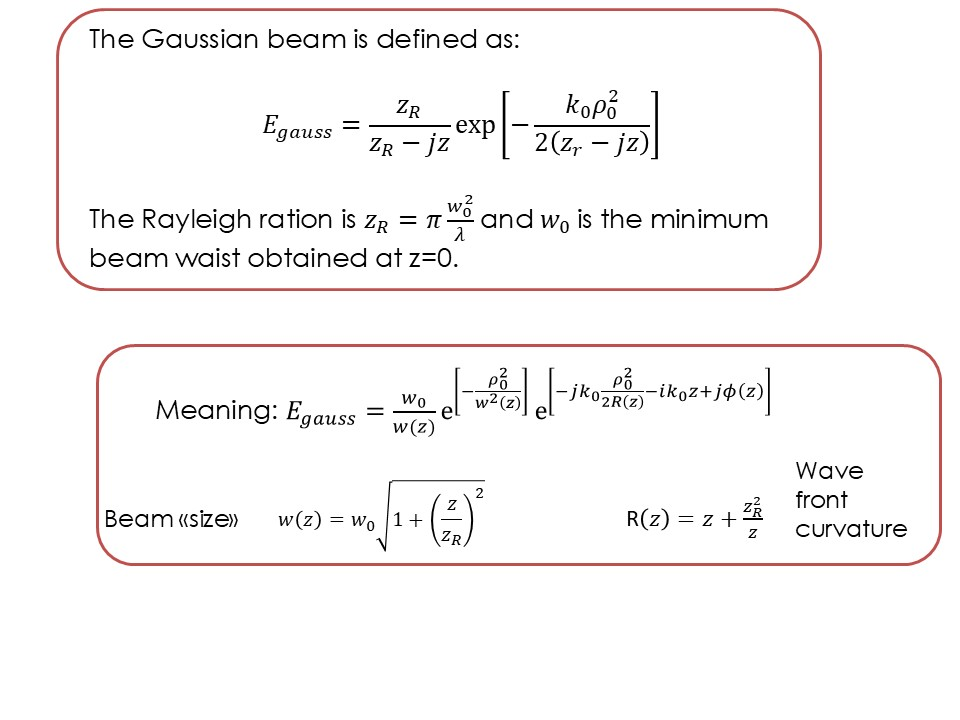


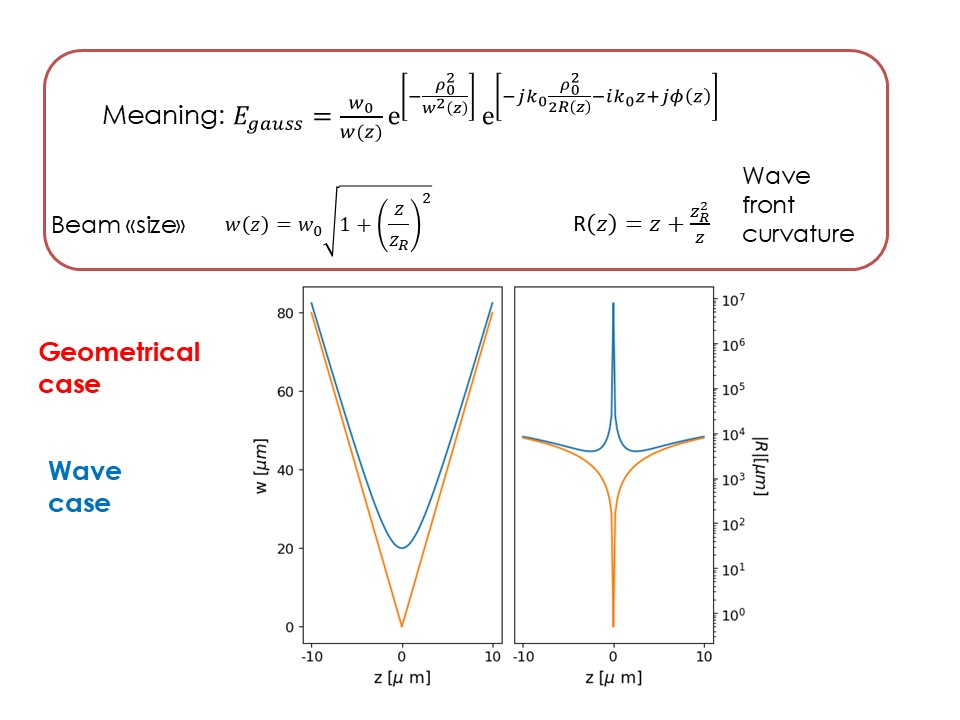

focal length =  9000  [um]
z= 8910.0  [um]; w0= 2 [um] ; zR= 19.79 [um]
512
zprop: 200 [um]
FWHM0 at  -90.0  [um] is  15.3  ; w0 9.188586427216341 [um]
FWHM at  110.0  [um] is   19.016927083333336  ; w0 11.420828633024806 [um]


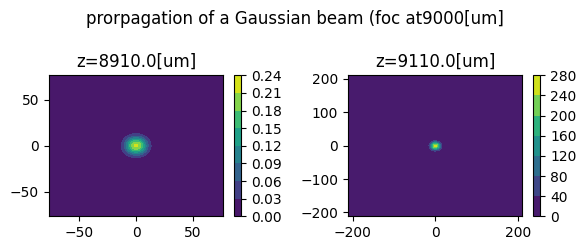

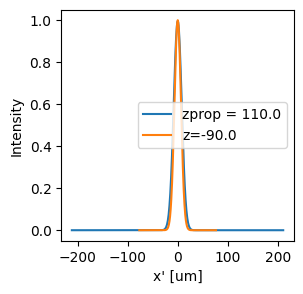

In [24]:
'''
March 2025
Giberto Chirico

Jupiter code to simulate the PROPAGATION  of a E field with the Fresnel integral
in real or in Fourier space.
For propation over a short distance (compared to the wavelngth) use the Fourier space
For a propagation over large distances use the direct space.

THIRD PANEL:

Here we  generate a Gaussian beam, real and imaginery part.
warning: the z axis is suich that z= focal length  means the position of the beam waist.
The Gbeam is focused at z = focal

'''

from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
from skimage import data
from skimage.color import rgb2gray


def Gaussbeam(xx,yy,z,k0,w0,foc):
    """ parameters
    wav  = wavelength in um
    w0= beam spot in um
    k0 = 2pi / lambda
    zR = Rayleigh range
    """
    zR = w0*w0*k0/2.
    zf = z-foc
    rr = xx**2 +yy**2
    Gbeam = zR/(zR-1j*zf) * np.exp(-k0*rr/(2*(zR-1j*zf)))
    """
    print ('comp w0 =',2*foc/(k0*w0)/np.sqrt(1 + (foc/zR)**2),' um')
    print ('Rayleigh range=',zR, 'EP diameter=', w0*np.sqrt(1 + (foc/zR)**2))
    print (zf)
    """
    return Gbeam
###################################################
def getFWHM(xv,matrice):
  mask = matrice >= 0.5
  crossings = np.where(np.diff(mask))[0]
  return xv[crossings[1]] - xv[crossings[0]]
########################################################

wav   = 0.635
kappa = 1/wav
k0 = 2*np.pi/wav
w0 = 2 # um

zR   = np.pi*w0**2/wav  ### in
foc  = 9000 # um
print ('focal length = ',foc,' [um]')
z    = foc*0.99  ##
print ('z=',z,' [um]; w0=',w0,'[um] ; zR=',np.round(zR,2), '[um]')


x     = np.linspace(-Npix//2,Npix//2-1,Npix) * upix
xx0,yy0 = np.meshgrid(x,x)

Gbeam = Gaussbeam(xx0,yy0,z,k0,w0,foc)
F,ax = plt.subplots(1,2,figsize=(6,2.5))
F.suptitle('prorpagation of a Gaussian beam (foc at'+str(foc)+'[um]')

im0 = ax[0].contourf(xx0,yy0,np.abs(Gbeam))
plt.colorbar(im0,ax=ax[0])
ax[0].set_title('z='+str(z)+'[um]')
print (Npix)

zprop = 200 # um
#x                   = np.linspace(-Npix//2,Npix//2-1,Npix) * upix
#xx0,yy0             = np.meshgrid(x,x)
rho02               = xx0**2+yy0**2
frequenze           = np.fft.fftshift(np.fft.fftfreq(Npix,upix))   ######SHIFTED !!!!!
xz                  = frequenze * wav * zprop
xxz,yyz             = np.meshgrid(xz,xz)
freq2x,freq2y       = np.meshgrid(frequenze,frequenze)       # also these are shifted

############## SHIFTED eFIELD

print ('zprop:',zprop,'[um]')

Eshifted      = np.exp(-1j*np.pi*kappa*rho02/zprop)*Gbeam   ### look at the signs! it is relevatn

Eshifted_fft  = np.fft.fftshift(np.fft.fft2(Eshifted))

propField     = np.flipud( np.abs(Eshifted_fft) )

im1  = ax[1].contourf(xxz,yyz,propField)
plt.colorbar(im1, ax=ax[1])
ax[1].set_title('z='+str(z+zprop)+'[um]')

plt.tight_layout()

plt.figure(figsize=(3,3))


A = np.abs(propField)[int(Npix//2),:]/np.max(np.abs(propField)) ### propagated field
A0 = np.abs(Gbeam)[int(Npix//2),:] / np.abs(Gbeam).max()        ##  original field

# diff(mask) is True where the mask changes (crossing points)
FWHM0   = getFWHM(xx0[int(Npix//2),:],A0)
FWHM    = getFWHM(xxz[int(Npix//2),:],A)
fattorew= np.sqrt(np.log(2))
print('FWHM0 at ',z-foc,' [um] is ',FWHM0,' ; w0',FWHM0/2/fattorew , '[um]')
print('FWHM at ', z+zprop-foc, ' [um] is  ',FWHM,' ; w0',FWHM/2/fattorew, '[um]')

plt.plot(xxz[int(Npix//2),:],A,label='zprop = '+str(-foc+(z+zprop)))
plt.plot(xx0[int(Npix//2),:],A0,label='z='+str(z-foc))
plt.xlabel('x\' [um]')
plt.ylabel('Intensity')
plt.legend()


z= 8999.1 ; w0= 2 zR= 15.707963267948966
focal length =  9000  [um]
k0= 7.853981633974483  at 1023
z= 8999.1 zprime= 9011.1
FOV= -256.0 255.5
norm= 0.9983626271075441 0.9983626271075442
normP= 0.126436396586828 0.8166731861456775
normC= 0.9983626271075441 0.8166731861456775
phase0 = -0.0 -0.05729577951305931
phaseP = 0.09624822501091343
phaseC = 0.0 0.7066479473280385


Text(0.5, 0.98, 'Normalized Gaussian beam at z=8999.1')

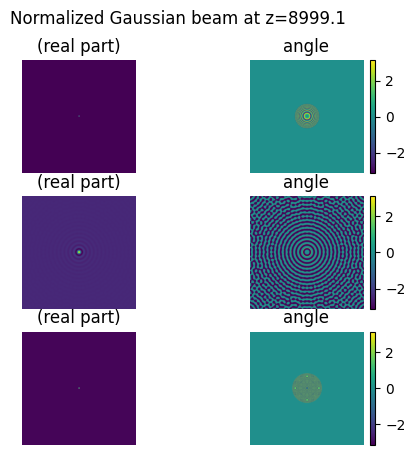

In [17]:
######################################################
### Gaussian beam and its propagation for very very short stretches
########### define the Fourier Kernel for the propagation
############## this is the routine to propagate the image
#############  PROPAGATION WITH THE FOURIER ALGORITHM

def FresnelKernel(k0,Freqx,Freqy,z):
  F2 = Freqx**2 + Freqy**2
  KF = np.zeros(F2.shape,dtype = 'complex')

  KF = np.exp( -1j * np.sqrt(np.abs(k0*k0-4*np.pi*np.pi*F2))*z)

  # Create a circular mask of radius = k0
  rows, cols = KF.shape
  center_row, center_col = rows // 2, cols // 2
  radius = 30  # Adjust the radius as needed
#### implement the mask for spatial frequencies above k0/2pi
  for index, value in enumerate(Freqx[0,:]):
        if value > k0/2/np.pi:
            radius = index
  print ('k0=',k0,' at',index)
  Y, X = np.ogrid[:rows, :cols]
  mask = (X - center_col)**2 + (Y - center_row)**2 <= radius**2

  # Apply the mask to the FFT spectrum
  masked_KF = KF * mask
  return masked_KF

####### image pars

NN2 = 512
NN = 2*NN2   ### in um
DDx = 0.5   ### pizel size in um

x = DDx* np.linspace(-NN2,NN2-1,NN)
y = DDx* np.linspace(-NN2,NN2-1,NN)

xx,yy = np.meshgrid(x,y)

frequenze           = np.fft.fftshift(np.fft.fftfreq(NN,DDx))   ######SHIFTED !!!!!
freq2x,freq2y       = np.meshgrid(frequenze,frequenze)       # also these are shifted


def Gaussbeam(xx,yy,z,k0,w0,foc):
    """ parameters
    wav  = wavelength in um
    w0= beam spot in um
    k0 = 2pi / lambda
    zR = Rayleigh range
    """
    zR = w0*w0*k0/2.
    zf = z-foc
    rr = xx**2 +yy**2
    Gbeam = zR/(zR-1j*zf) * np.exp(-k0*rr/(2*(zR-1j*zf)))
    """
    print ('comp w0 =',2*foc/(k0*w0)/np.sqrt(1 + (foc/zR)**2),' um')
    print ('Rayleigh range=',zR, 'EP diameter=', w0*np.sqrt(1 + (foc/zR)**2))
    print (zf)
    """
    return Gbeam

#########################  MAIN
######################## FT propagation

wav = 0.8 ### um
k0 = 2*np.pi/wav

w0 = 2 # um
zR = np.pi*w0**2/wav  ### in
print ('z=',z,'; w0=',w0,'zR=',zR)
foc = 9000 # um
print ('focal length = ',foc,' [um]')

z   = foc*0.9999

Gbeam = Gaussbeam(xx,yy,z,k0,w0,foc)

# Perform FFT
Eprop_z0    = Gbeam
zprop       = 12
#print ('ll',k0*zprop,z+zprop)
masked_KF = FresnelKernel(k0,freq2x,freq2y,zprop)   ## propagation kernel, notice the freq are shifted - so "human"

zstep = 1
for i in range (zstep):
  Efft2       =  np.fft.fftshift(np.fft.fft2(Eprop_z0))                  # this is used for the propagation
  Eprop_z     = np.fft.fft2(np.fft.fftshift(Efft2 * masked_KF))  ## propagation
  Eprop_z0    = np.fliplr(np.flipud(Eprop_z))
  Eprop_z0    = np.roll(np.roll(Eprop_z0, shift=1, axis=1), shift=1, axis=0)  # shift right by 1
#####check
Eprop_z = Eprop_z0
zprime  = z+zprop*zstep
print ('z=',z,'zprime=',zprime)

Gbeam_C = Gaussbeam(xx,yy, z + zprop*zstep ,k0,w0,foc)

#### check by plot the Gaussian Beam
figc, axc = plt.subplots(3,2,figsize = (5,5))
for aa in axc.ravel():
    aa.axis('off')

norm = np.max(np.abs(Gbeam))
print ('FOV=',x.min(),x.max())

AA = Gbeam/norm

normP = np.max(np.abs(Eprop_z))
BB    = Eprop_z/normP

normC = np.max(np.abs(Gbeam_C))
CC    = Gbeam_C/normC

print ('norm=',norm,zR/np.sqrt(zR**2+(z-foc)**2))
print ('normP=',normP/NN/NN,zR/np.sqrt(zR**2+(zprime-foc)**2))
print ('normC=',norm,zR/np.sqrt(zR**2+(zprime-foc)**2))

theta = (z-foc)/zR
theta = (theta + np.pi) % (2 * np.pi) - np.pi
print ('phase0 =',np.angle(Gbeam)[0,0],theta)
print ('phaseP =',np.angle(Eprop_z)[0,0])
theta = (zprime-foc)/zR
theta = (theta + np.pi) % (2 * np.pi) - np.pi
print ('phaseC =',np.angle(Gbeam_C)[0,0,],theta)


axc[0,0].imshow((AA.real))
axc[0,0].set_title( '(real part)')
imA0 = axc[0,1].imshow(np.angle(AA))
figc.colorbar(imA0, ax=axc[0,1], location='right', fraction=0.046, pad=0.04)
axc[0,1].set_title('angle')

axc[1,0].imshow((BB.real))
axc[1,0].set_title( '(real part)')
imA1 = axc[1,1].imshow(np.angle(BB))
figc.colorbar(imA1, ax=axc[1,1], location='right', fraction=0.046, pad=0.04)
axc[1,1].set_title('angle')

axc[2,0].imshow((CC.real))
axc[2,0].set_title( '(real part)')
imA2 = axc[2,1].imshow(np.angle(CC))
figc.colorbar(imA2, ax=axc[2,1], location='right', fraction=0.046, pad=0.04)
axc[2,1].set_title('angle')

figc.suptitle('Normalized Gaussian beam at z='+str(z))



Text(0.5, 1.0, 'zprop:12[um]')

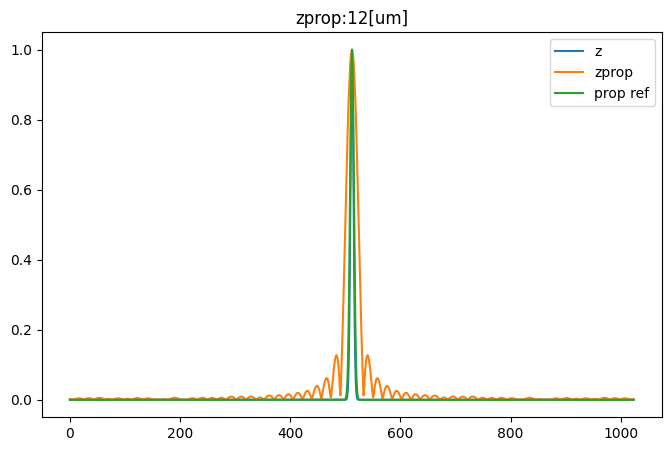

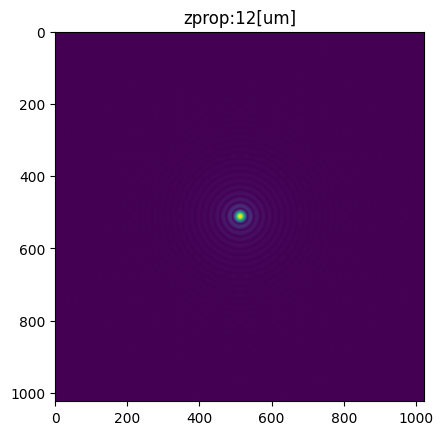

In [18]:
II = np.abs(AA)[NN//2,:]
IIp = np.abs(BB)[NN//2,:]
IIc = np.abs(CC)[NN//2,:]
plt.figure(figsize=(8, 5))
plt.plot(II,label='z')
plt.plot(IIp,label='zprop')
plt.plot(IIc,label='prop ref')
plt.legend()
plt.title('zprop:'+str(zprop)+'[um]')

plt.figure()
plt.imshow(np.abs(BB))
plt.title('zprop:'+str(zprop)+'[um]')

z= 8910.0 ; w0= 2 zR= 15.707963267948966
focal length =  9000  [um]
k0= 7.853981633974483  at 511
zstep= 20
FOV= -128.0 127.5
norm= 0.7556109803921569 0.17193386713052058
normP= 0.8026246065000044 0.8166731861456775


Text(0.5, 0.98, 'propagated at z=20[um]')

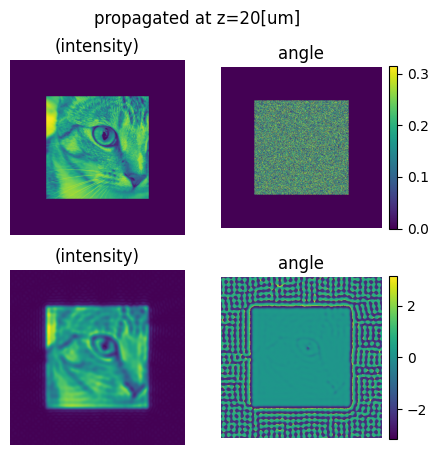

In [25]:
######################################################
### FT propagation of the cat image
########### define the Fourier Kernel for the propagation
############## this is the routine to propagate the image

def FresnelKernel(k0,Freqx,Freqy,z):
  F2 = Freqx**2 + Freqy**2
  KF = np.zeros(F2.shape,dtype = 'complex')

  KF = np.exp( -1j * np.sqrt(np.abs(k0*k0-4*np.pi*np.pi*F2))*z)

  # Create a circular mask of radius = k0
  rows, cols = KF.shape
  center_row, center_col = rows // 2, cols // 2
  radius = 30  # Adjust the radius as needed
#### implement the mask for spatial frequencies above k0/2pi
  for index, value in enumerate(Freqx[0,:]):
        if value > k0/2/np.pi:
            radius = index
  print ('k0=',k0,' at',index)
  Y, X = np.ogrid[:rows, :cols]
  mask = (X - center_col)**2 + (Y - center_row)**2 <= radius**2

  # Apply the mask to the FFT spectrum
  masked_KF = KF * mask
  return masked_KF

####### image pars

NN2 = image_array.shape[0]//2
NN = 2*NN2   ### in um
DDx = 0.5   ### pizel size in um

x = DDx* np.linspace(-NN2,NN2-1,NN)
y = DDx* np.linspace(-NN2,NN2-1,NN)

xx,yy = np.meshgrid(x,y)

frequenze           = np.fft.fftshift(np.fft.fftfreq(NN,DDx))   ######SHIFTED !!!!!
freq2x,freq2y       = np.meshgrid(frequenze,frequenze)       # also these are shifted

#########################  MAIN
######################## FT propagation

wav = 0.8 ### um
k0 = 2*np.pi/wav

w0 = 2 # um
zR = np.pi*w0**2/wav  ### in
print ('z=',z,'; w0=',w0,'zR=',zR)
foc = 9000 # um
print ('focal length = ',foc,' [um]')

# Perform FFT  with random phase
csicsi = 0.1
Eprop_z0    = image_array* np.exp( 1j*np.pi*csicsi* np.random.rand(NN,NN))

#################   CHANGE HERE THE PROPAGATION LENGHT
zprop       = 20
#print ('ll',k0*zprop,z+zprop)
masked_KF = FresnelKernel(k0,freq2x,freq2y,zprop)   ## propagation kernel, notice the freq are shifted - so "human"

Efft2       =  np.fft.fftshift(np.fft.fft2(Eprop_z0))                  # this is used for the propagation
Eprop_z     = np.fft.fft2(np.fft.fftshift(Efft2 * masked_KF))  ## propagation
Eprop_z     = np.fliplr(Eprop_z)
Eprop_z     = np.flipud(Eprop_z)

print ('zstep=',zprop)


#### check by plot the Gaussian Beam
figc, axc = plt.subplots(2,2,figsize = (5,5))
for aa in axc.ravel():
    aa.axis('off')

norm = np.max(np.abs(Eprop_z0))
print ('FOV=',x.min(),x.max())

AA = Eprop_z0/norm

normP = np.max(np.abs(Eprop_z))
BB    = Eprop_z/normP

print ('norm=',norm,zR/np.sqrt(zR**2+(z-foc)**2))
print ('normP=',normP/NN/NN,zR/np.sqrt(zR**2+(zprime-foc)**2))

axc[0,0].imshow((np.abs(AA)))
axc[0,0].set_title( '(intensity)')
imA0 = axc[0,1].imshow(np.angle(AA))
figc.colorbar(imA0, ax=axc[0,1], location='right', fraction=0.046, pad=0.04)
axc[0,1].set_title('angle')

axc[1,0].imshow(np.abs(BB))
axc[1,0].set_title( '(intensity)')
imA1 = axc[1,1].imshow(np.angle(BB))
figc.colorbar(imA1, ax=axc[1,1], location='right', fraction=0.046, pad=0.04)
axc[1,1].set_title('angle')


figc.suptitle('propagated at z='+str(zprop)+'[um]')

